In [54]:
import pandas as pd
import numpy as np 
from sentence_transformers import SentenceTransformer

In [56]:
df = pd.read_csv(
    "zuno_dataset.csv"
)
df.head()
df_small = df.copy()
df['combined_text'] = (
    df['song'].astype(str)
    + " "
    + df['artist'].astype(str)
    + " "
    + df['genre'].astype(str)
    + " "
    + df['lyrics'].astype(str)
)
model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

print("Model Loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model Loaded


In [58]:
embeddings = model.encode(
    df['combined_text'].tolist(),
    show_progress_bar=True
)
print(
    embeddings.shape
)

Batches:   0%|          | 0/43 [00:00<?, ?it/s]

(1360, 384)


In [59]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(
    embeddings
)

In [60]:
user_history = df.sample(
    50,
    random_state=42
)
user_history.head()

,song,artist,genre,popularity,lyrics,combined_text
51,the universal,blur,alt-rock,1,This is the next century The Universal is f...,the universal blur alt-rock This is the next c...
1101,green is the colour,pink floyd,psych-rock,46,Heavy hung the canopy of blue Shade my eyes...,green is the colour pink floyd psych-rock Heav...
1313,watch me bleed,tears for fears,synth-pop,44,Heaven comes to he who waits But I know I'm...,watch me bleed tears for fears synth-pop Heave...
514,not alone,linkin park,grunge,56,"I break down, fear is sinking in The cold c...","not alone linkin park grunge I break down, fea..."
1075,brain damage,pink floyd,psych-rock,66,The lunatic is on the grass. The lunatic is...,brain damage pink floyd psych-rock The lunatic...


In [61]:
print(
    "Songs Discovered:",
    len(user_history)
)

print(
    "Unique Artists:",
    user_history[
        'artist'
    ].nunique()
)

Songs Discovered: 50
Unique Artists: 42


In [62]:
top_genres = (
    user_history['genre']
    .value_counts()
    .head(10)
)

top_genres

genre
grunge         7
alt-rock       5
hard-rock      5
synth-pop      3
piano          3
death-metal    3
psych-rock     3
edm            2
honky-tonk     2
dance          2
Name: count, dtype: int64

In [63]:
import matplotlib.pyplot as plt

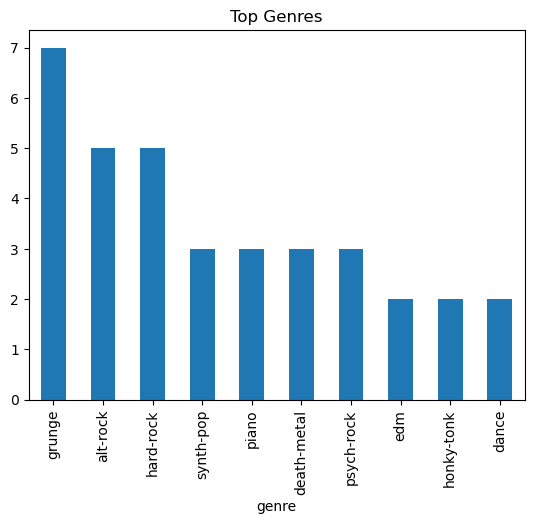

In [64]:
top_genres.plot(
    kind='bar'
)

plt.title(
    "Top Genres"
)

plt.show()

In [65]:
top_artists = (
    user_history['artist']
    .value_counts()
    .head(10)
)

top_artists

artist
linkin park        4
pink floyd         3
billy joel         2
ellie goulding     2
adele              2
our lady peace     1
soundgarden        1
foreigner          1
abba               1
louis armstrong    1
Name: count, dtype: int64

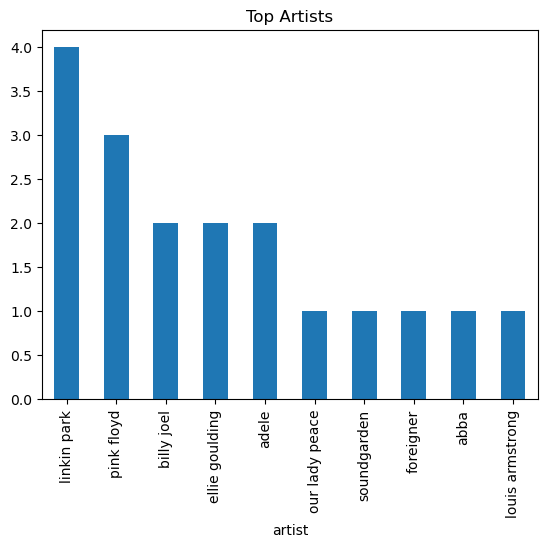

In [66]:
top_artists.plot(
    kind='bar'
)

plt.title(
    "Top Artists"
)

plt.show()

In [67]:
favorite_genre = (
    user_history[
        'genre'
    ]
    .mode()[0]
)

print(
    favorite_genre
)

grunge


In [68]:
favorite_artist = (
    user_history[
        'artist'
    ]
    .mode()[0]
)

print(
    favorite_artist
)

linkin park


In [69]:
discovery_score = (

    user_history[
        'artist'
    ].nunique()

    /

    len(user_history)

) * 100

print(
    round(
        discovery_score,
        2
    )
)

84.0


In [70]:
wrapped = {

    "Songs Discovered":
        len(user_history),

    "Unique Artists":
        user_history[
            'artist'
        ].nunique(),

    "Favorite Genre":
        favorite_genre,

    "Favorite Artist":
        favorite_artist,

    "Discovery Score":
        round(
            discovery_score,
            2
        )
}

In [71]:
for key,value in wrapped.items():

    print(
        f"{key}: {value}"
    )

Songs Discovered: 50
Unique Artists: 42
Favorite Genre: grunge
Favorite Artist: linkin park
Discovery Score: 84.0


In [72]:
embeddings = np.load(
    "zuno_embeddings.npy"
)

In [81]:
from sklearn.cluster import KMeans

In [82]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(
    embeddings
)

In [26]:
print(len(clusters))
print(len(df))

1000
1360


In [51]:
df_small = df.head(1000).copy()

In [79]:
df_small['cluster'] = clusters

In [80]:
embeddings = model.encode(
    df_small['combined_text'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [30]:
import numpy as np

np.save(
    "zuno_embeddings.npy",
    embeddings
)

In [31]:
len(embeddings)

1000

In [77]:
print(df.shape)
print(embeddings.shape)
print(len(clusters))

(1360, 6)
(1000, 384)
1000


In [78]:
df_small = df.head(1000).copy()

In [83]:
len(clusters)

1000

In [4]:
import pandas as pd

df = pd.read_csv("zuno_dataset.csv")

print(df.shape)
df

(1360, 5)


,song,artist,genre,popularity,lyrics
0,i'm yours,jason mraz,acoustic,80,Well you done done me and you bet I felt it ...
1,i won't give up,jason mraz,acoustic,69,When I look into your eyes It's like watchi...
2,93 million miles,jason mraz,acoustic,0,93 million miles from the sun People get re...
3,bella luna,jason mraz,acoustic,1,Mystery the moon A hole in the sky A sup...
4,winter wonderland,jason mraz,acoustic,0,"Sleigh bells ring, are you listening, In th..."
...,...,...,...,...,...
1355,steady my heart,kari jobe,world-music,43,Wish it could be easy Why is life so messy ...
1356,here i am to worship,michael w. smith,world-music,43,Light of the World You stepped down into da...
1357,i will be here for you,michael w. smith,world-music,53,When you feel the sunlight Fade into the co...
1358,ancient words,michael w. smith,world-music,41,Holy words long preserved For our walk in t...


In [6]:
df['combined_text'] = (
    df['song'].astype(str)
    + " "
    + df['artist'].astype(str)
    + " "
    + df['genre'].astype(str)
    + " "
    + df['lyrics'].astype(str)
)

In [7]:
from sentence_transformers import SentenceTransformer

In [8]:
model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

print("Model Loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model Loaded


In [9]:
embeddings = model.encode(
    df['combined_text'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/43 [00:00<?, ?it/s]

In [10]:
print(df.shape)

print(embeddings.shape)

(1360, 6)
(1360, 384)


In [11]:
from sklearn.cluster import KMeans

In [12]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(
    embeddings
)

print(len(clusters))

1360


In [13]:
df['cluster'] = clusters

In [14]:
df[
[
'song',
'cluster'
]
].head()

,song,cluster
0,i'm yours,2
1,i won't give up,2
2,93 million miles,1
3,bella luna,1
4,winter wonderland,1


In [15]:
print(df.shape)
print(embeddings.shape)
print(len(clusters))

(1360, 7)
(1360, 384)
1360


In [16]:
df['cluster'] = clusters

In [17]:
df[
[
'song',
'artist',
'cluster'
]
].head()

,song,artist,cluster
0,i'm yours,jason mraz,2
1,i won't give up,jason mraz,2
2,93 million miles,jason mraz,1
3,bella luna,jason mraz,1
4,winter wonderland,jason mraz,1


In [26]:
user_history = df.sample(
    50,
    random_state=42
)

In [27]:
df['cluster'] = clusters

In [29]:
favorite_cluster = (
    user_history['cluster']
    .mode()[0]
)

print(favorite_cluster)

2


In [28]:
print(user_history.columns)

Index(['song', 'artist', 'genre', 'popularity', 'lyrics', 'combined_text',
       'cluster'],
      dtype='object')


In [30]:
favorite_genre = (
    user_history['genre']
    .mode()[0]
)

print(
    "Favorite Genre:",
    favorite_genre
)

Favorite Genre: grunge


In [31]:
favorite_artist = (
    user_history['artist']
    .mode()[0]
)

print(
    "Favorite Artist:",
    favorite_artist
)

Favorite Artist: linkin park


In [32]:
discovery_score = (

    user_history['artist']
    .nunique()

    /

    len(user_history)

) * 100

print(
    round(
        discovery_score,
        2
    )
)

84.0


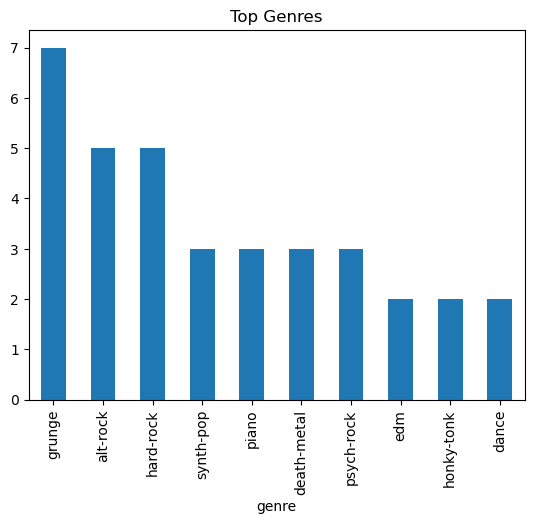

In [33]:
import matplotlib.pyplot as plt

top_genres = (
    user_history['genre']
    .value_counts()
    .head(10)
)

top_genres.plot(
    kind='bar'
)

plt.title(
    "Top Genres"
)

plt.show()

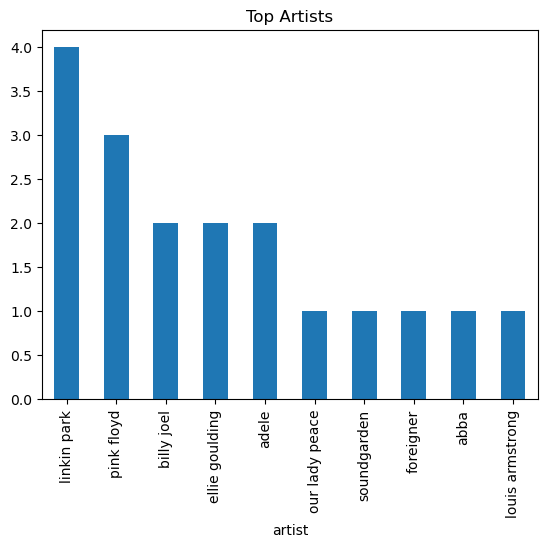

In [34]:
top_artists = (
    user_history['artist']
    .value_counts()
    .head(10)
)

top_artists.plot(
    kind='bar'
)

plt.title(
    "Top Artists"
)

plt.show()

In [35]:
wrapped = {

    "Songs Discovered":
        len(user_history),

    "Unique Artists":
        user_history[
            'artist'
        ].nunique(),

    "Favorite Genre":
        favorite_genre,

    "Favorite Artist":
        favorite_artist,

    "Favorite Cluster":
        int(
            favorite_cluster
        ),

    "Discovery Score":
        round(
            discovery_score,
            2
        )
}

In [36]:
for key,value in wrapped.items():

    print(
        f"{key}: {value}"
    )

Songs Discovered: 50
Unique Artists: 42
Favorite Genre: grunge
Favorite Artist: linkin park
Favorite Cluster: 2
Discovery Score: 84.0


In [37]:
cluster_size = len(

    user_history[
        user_history[
            'cluster'
        ]
        ==
        favorite_cluster
    ]
)

print(
f"""
🎵 ZUNO AI INSIGHT

Your listening behavior is
centered around Cluster
{favorite_cluster}.

Songs in this cluster:
{cluster_size}

Favorite Genre:
{favorite_genre}

Favorite Artist:
{favorite_artist}

Discovery Score:
{round(discovery_score,2)}
"""
)


🎵 ZUNO AI INSIGHT

Your listening behavior is
centered around Cluster
2.

Songs in this cluster:
16

Favorite Genre:
grunge

Favorite Artist:
linkin park

Discovery Score:
84.0



In [38]:
wrapped_df = pd.DataFrame(
    [wrapped]
)

wrapped_df.to_csv(
    "zuno_wrapped.csv",
    index=False
)

print(
    "Wrapped Saved Successfully"
)

Wrapped Saved Successfully


In [39]:
user_history.to_csv(
    "user_history.csv",
    index=False
)

print(
    "User History Saved"
)

User History Saved
